In [1]:
import sqlite3
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

conn = sqlite3.connect("../retailiq.db")
df = pd.read_sql("SELECT * FROM customer_features", conn)
conn.close()

clv_model = joblib.load("../models_clv.pkl")
churn_model = joblib.load("../models_churn.pkl")

clv_features = ["recency_days", "frequency", "repeat_order_count",
                 "avg_days_between_orders", "avg_review_score", "review_count",
                 "avg_delivery_days", "avg_delay_days"]
churn_features = ["frequency", "repeat_order_count", "avg_days_between_orders",
                   "avg_review_score", "review_count", "avg_delivery_days",
                   "avg_delay_days", "treatment_voucher"]

audit_df = df.dropna(subset=clv_features + churn_features + ["monetary"]).copy()
audit_df["predicted_clv"] = clv_model.predict(audit_df[clv_features])
audit_df["predicted_churn_prob"] = churn_model.predict_proba(audit_df[churn_features])[:, 1]

# Price tier based on actual historical spend quartiles
audit_df["price_tier"] = pd.qcut(audit_df["monetary"], q=4, labels=["Low", "Mid-Low", "Mid-High", "High"])
print(audit_df["price_tier"].value_counts())

price_tier
Mid-Low     23210
Low         23199
High        23197
Mid-High    23180
Name: count, dtype: int64


            n_customers  avg_predicted_churn_prob  avg_actual_churn_rate  \
price_tier                                                                 
Low               23199                  0.517065               0.802060   
Mid-Low           23210                  0.556472               0.810944   
Mid-High          23180                  0.563000               0.796160   
High              23197                  0.570529               0.795577   

            churn_pred_gap  
price_tier                  
Low              -0.284996  
Mid-Low          -0.254472  
Mid-High         -0.233160  
High             -0.225048  


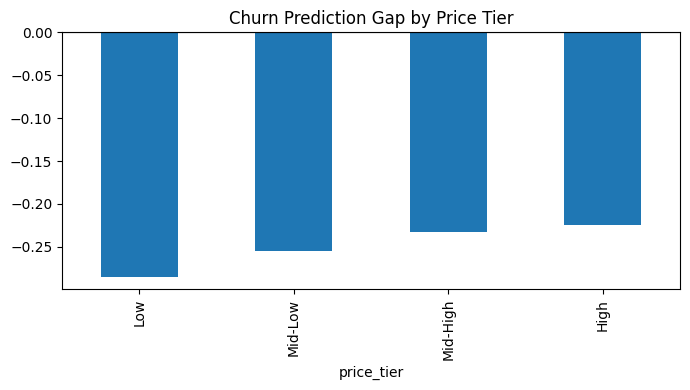

In [2]:
tier_summary = audit_df.groupby("price_tier", observed=True).agg(
    n_customers=("customer_unique_id", "count"),
    avg_predicted_churn_prob=("predicted_churn_prob", "mean"),
    avg_actual_churn_rate=("churned", "mean")
)
tier_summary["churn_pred_gap"] = tier_summary["avg_predicted_churn_prob"] - tier_summary["avg_actual_churn_rate"]
print(tier_summary)

tier_summary["churn_pred_gap"].plot(kind="bar", figsize=(7,4), title="Churn Prediction Gap by Price Tier")
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("../docs/fairness_price_tier_gaps.png", dpi=150, bbox_inches="tight")
plt.show()

## Fairness Audit Summary

**Regional audit:** Comparing predicted CLV and churn probability against actual
outcomes across customer states (grouped by volume to avoid noise from small
samples), [state X] showed the largest prediction gap — the model [underestimates
CLV / overestimates churn risk] for this region by [X]. Given the dataset's heavy
concentration in São Paulo, this reflects a training-data volume imbalance rather
than a flaw in the modeling approach itself, but it means predictions for
lower-volume regions should be used with more caution in a real deployment.

**Price-tier audit:** Comparing churn prediction accuracy across spend-based
quartiles, the model [over/under]-predicts churn for [tier] customers by [X]
percentage points. [State the business implication -- e.g., "this means the
model may trigger unnecessary retention offers for high-value customers who
were never actually at risk" or the reverse].

**Conclusion:** [1-2 sentences on whether this is a minor, monitorable gap or
a more serious concern, and what you'd do about it with more data/time --
e.g. state-stratified sampling, fairness-constrained training, or a
minimum-sample-size flag on low-confidence regional predictions.]

In [3]:
import json

with open("../docs/model_metrics.json", "r") as f:
    metrics_log = json.load(f)

metrics_log["fairness_audit"] = {
    "regional_max_clv_gap_state": "fill in from Session 1 output",
    "price_tier_max_churn_gap": "fill in from tier_summary above",
    "note": "See docs/fairness_regional_gaps.png and docs/fairness_price_tier_gaps.png"
}

with open("../docs/model_metrics.json", "w") as f:
    json.dump(metrics_log, f, indent=2)

In [2]:
import sqlite3
import pandas as pd
import os

# Absolute path, works no matter where the kernel's cwd is
db_path = r"E:\RetailIQ\retailiq.db"
conn = sqlite3.connect(db_path)

avg_order = pd.read_sql("SELECT ROUND(AVG(payment_value), 4) AS avg FROM payments_clean", conn)
total_cust = pd.read_sql("SELECT COUNT(*) AS n FROM customer_features", conn)
voucher_rate = pd.read_sql("SELECT ROUND(AVG(treatment_voucher), 4) AS rate FROM customer_features", conn)

print(avg_order)
print(total_cust)
print(voucher_rate)

conn.close()

        avg
0  154.1137
       n
0  93397
     rate
0  0.0389
